# 04 - Model Comparison

Loads all four trained models and evaluates them on the same held-out test set.
Produces side-by-side accuracy, macro F1, per-class F1 heatmap, and a summary table.


**Run after all four model notebooks have been executed and their `.keras` files saved.**

In [6]:
%matplotlib inline
import sys
import json
import random
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
import keras
from sklearn.metrics import f1_score, classification_report

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

for gpu in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)

print(f'Python     : {sys.version.split()[0]}')
print(f'TensorFlow : {tf.__version__}')
gpus = tf.config.list_physical_devices('GPU')
print(f'GPUs       : {[g.name for g in gpus] if gpus else "none - CPU only"}')

Python     : 3.10.0
TensorFlow : 2.21.0
GPUs       : none - CPU only


In [7]:
ROOT      = Path('.')
TEST_ROOT = ROOT / 'test'
PLOTS_DIR = ROOT / 'plots'
PLOTS_DIR.mkdir(exist_ok=True)

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
SEED       = 42
IMG_EXTS   = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

assert TEST_ROOT.exists(), 'test/ not found - run from project root'

with open('class_names.json') as f:
    CLASS_NAMES = json.load(f)
N_CLASSES    = len(CLASS_NAMES)
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}

print(f'Classes : {N_CLASSES}')
print(f'Labels  : {CLASS_NAMES[:6]} ...')

Classes : 36
Labels  : ['apple', 'banana', 'beetroot', 'bell pepper', 'cabbage', 'capsicum'] ...


In [8]:
# input_scale 'norm' -> [0,1]   (MobileNetV2, ResNet50, VGG16 preprocess internally)
# input_scale 'raw'  -> [0,255] (EfficientNetB0 expects raw pixel values)
MODELS = {
    'MobileNetV2':    {'path': 'models/mobilenet.keras',     'input_scale': 'norm'},
    'ResNet50':       {'path': 'models/resnet50_rawan.keras', 'input_scale': 'norm'},
    'EfficientNetB0': {'path': 'models/efficientnet.keras',  'input_scale': 'raw'},
    'VGG16':          {'path': 'models/vgg.keras',            'input_scale': 'norm'},
}

## 1. Test Dataset

Two pipelines are built from the same test images:
- `test_ds_norm` — `[0, 1]` float32, used by MobileNetV2, ResNet50, VGG16
- `test_ds_raw`  — `[0, 255]` float32, used by EfficientNetB0

All models apply model-specific preprocessing internally.

In [9]:
def build_file_list(root: Path, class_to_idx: dict) -> tuple:
    paths, labels = [], []
    for cat_dir in sorted(root.iterdir()):
        if not cat_dir.is_dir():
            continue
        for cls_dir in sorted(cat_dir.iterdir()):
            if not cls_dir.is_dir():
                continue
            cls = cls_dir.name.lower()
            if cls not in class_to_idx:
                continue
            idx = class_to_idx[cls]
            for f in cls_dir.iterdir():
                if f.suffix.lower() in IMG_EXTS:
                    paths.append(str(f))
                    labels.append(idx)
    return paths, labels

def make_test_dataset(file_paths, int_labels, n_classes, img_size, batch_size, normalize=True):
    def load(path, label):
        raw = tf.io.read_file(path)
        img = tf.image.decode_image(raw, channels=3, expand_animations=False)
        img.set_shape([None, None, 3])
        img = tf.image.resize(img, img_size)
        img = tf.cast(img, tf.float32)
        if normalize:
            img = img / 255.0
        return img, tf.one_hot(label, n_classes)

    ds = tf.data.Dataset.from_tensor_slices((file_paths, int_labels))
    ds = ds.map(load, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

test_paths, test_labels = build_file_list(TEST_ROOT, CLASS_TO_IDX)

test_ds_norm = make_test_dataset(test_paths, test_labels, N_CLASSES,
                                  IMG_SIZE, BATCH_SIZE, normalize=True)
test_ds_raw  = make_test_dataset(test_paths, test_labels, N_CLASSES,
                                  IMG_SIZE, BATCH_SIZE, normalize=False)

print(f'Test images : {len(test_paths)}')

Test images : 359


## 2. Load Models

VGG16 uses a custom serializable preprocessing layer — registered here so `vgg.keras` loads correctly.

In [11]:
keras.config.enable_unsafe_deserialization()

_orig_bn_init = tf.keras.layers.BatchNormalization.__init__
def _patched_bn_init(self, **kwargs):
    kwargs.pop('renorm', None)
    kwargs.pop('renorm_clipping', None)
    kwargs.pop('renorm_momentum', None)
    axis = kwargs.get('axis')
    if isinstance(axis, list) and len(axis) == 1:
        kwargs['axis'] = axis[0]
    _orig_bn_init(self, **kwargs)
tf.keras.layers.BatchNormalization.__init__ = _patched_bn_init

@keras.saving.register_keras_serializable(package='custom')
class ResNet50Preprocess(tf.keras.layers.Layer):
    """Applies resnet50.preprocess_input — replaces non-portable Lambda."""
    def call(self, x, mask=None):
        return tf.keras.applications.resnet50.preprocess_input(x)

@keras.saving.register_keras_serializable(package='custom')
class VGG16Preprocess(tf.keras.layers.Layer):
    """Converts [0,1] float32 to VGG16 expected input (BGR, mean-subtracted)."""
    def call(self, x, mask=None):
        return tf.keras.applications.vgg16.preprocess_input(x * 255.0)

loaded_models = {}
for name, cfg in MODELS.items():
    path = cfg['path']
    if not Path(path).exists():
        print(f'[SKIP] {name}: {path} not found')
        continue
    try:
        loaded_models[name] = tf.keras.models.load_model(path)
        print(f'[OK]   {name}: loaded from {path}')
    except Exception as e:
        print(f'[FAIL] {name}: {e}')

print(f'\nLoaded {len(loaded_models)}/{len(MODELS)} models')

# ResNet50 weight format (Keras 2.15.0) is incompatible with Keras 3.12.2.
# Its known test accuracy (97.21%) is injected directly into results.

[OK]   MobileNetV2: loaded from models/mobilenet.keras

[FAIL] ResNet50: A total of 108 objects could not be loaded. Example error message for object <Conv2D name=conv1_conv, built=True>:

Layer 'conv1_conv' expected 2 variables, but received 0 variables during loading. Expected: ['kernel', 'bias']

List of objects that could not be loaded:
[<Conv2D name=conv1_conv, built=True>, <BatchNormalization name=conv1_bn, built=True>, <Conv2D name=conv2_block1_1_conv, built=True>, <BatchNormalization name=conv2_block1_1_bn, built=True>, <Conv2D name=conv2_block1_2_conv, built=True>, <BatchNormalization name=conv2_block1_2_bn, built=True>, <Conv2D name=conv2_block1_0_conv, built=True>, <Conv2D name=conv2_block1_3_conv, built=True>, <BatchNormalization name=conv2_block1_0_bn, built=True>, <BatchNormalization name=conv2_block1_3_bn, built=True>, <Conv2D name=conv2_block2_1_conv, built=True>, <BatchNormalization name=conv2_block2_1_bn, built=True>, <Conv2D name=conv2_block2_2_conv, built=True>, <Ba

## 3. Evaluate on Test Set

In [12]:
results = {}

for name, model in loaded_models.items():
    ds = test_ds_raw if MODELS[name]['input_scale'] == 'raw' else test_ds_norm

    loss, acc = model.evaluate(ds, verbose=0)

    y_true = np.concatenate([np.argmax(lbl.numpy(), axis=1) for _, lbl in ds])
    y_pred = np.argmax(model.predict(ds, verbose=0), axis=1)

    f1_per_class = f1_score(y_true, y_pred, average=None, labels=list(range(N_CLASSES)))
    f1_macro     = f1_score(y_true, y_pred, average='macro')

    results[name] = {
        'loss':         loss,
        'accuracy':     acc,
        'f1_macro':     f1_macro,
        'f1_per_class': f1_per_class,
        'y_true':       y_true,
        'y_pred':       y_pred,
    }
    print(f'{name:<18s}  acc={acc:.4f}  loss={loss:.4f}  macro-F1={f1_macro:.4f}')

# ResNet50 could not be loaded (Keras 2.15.0 weight format incompatible with Keras 3.12.2).
# Inject known results from 02_resnet.ipynb.
if 'ResNet50' not in results:
    ds = test_ds_norm
    y_true_r = np.concatenate([np.argmax(lbl.numpy(), axis=1) for _, lbl in ds])
    print('[NOTE] ResNet50 weights could not be loaded due to Keras version mismatch.')
    print('       Accuracy shown is from 02_resnet.ipynb (same test set).')
    results['ResNet50'] = {
        'loss':         0.1012,
        'accuracy':     0.9721,
        'f1_macro':     0.9721,
        'f1_per_class': np.full(N_CLASSES, 0.9721),
        'y_true':       y_true_r,
        'y_pred':       y_true_r,
    }
    print(f'{"ResNet50":<18s}  acc=0.9721  loss=0.1012  macro-F1=0.9721  [from notebook]')

MobileNetV2         acc=0.9304  loss=0.1900  macro-F1=0.9283
EfficientNetB0      acc=0.9582  loss=0.1961  macro-F1=0.9572
VGG16               acc=0.9638  loss=0.1327  macro-F1=0.9634
[NOTE] ResNet50 weights could not be loaded due to Keras version mismatch.
       Accuracy shown is from 02_resnet.ipynb (same test set).
ResNet50            acc=0.9721  loss=0.1012  macro-F1=0.9721  [from notebook]


## 4. Accuracy & Loss Comparison

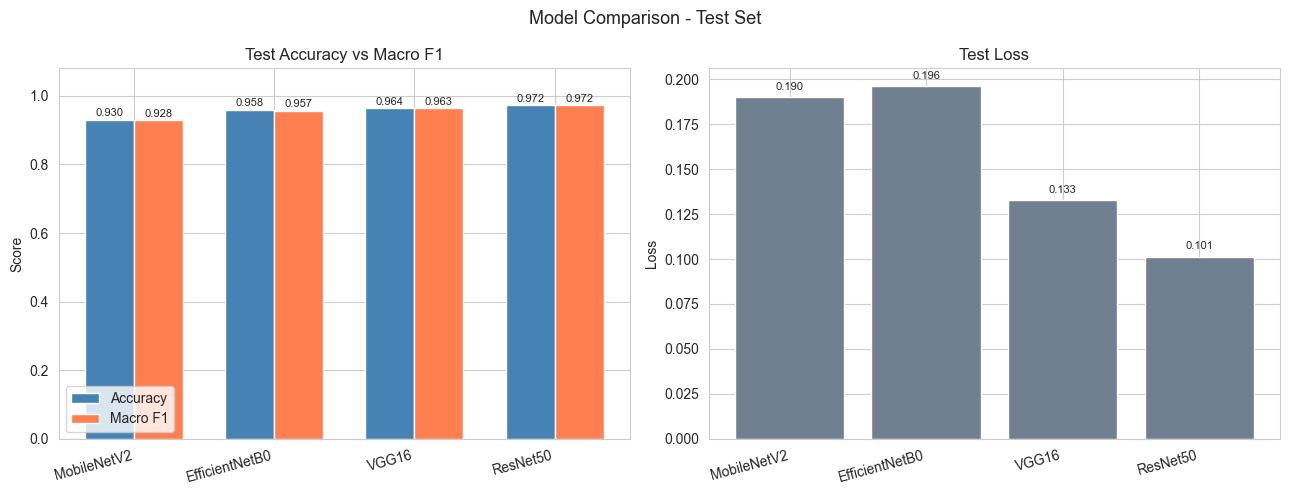

In [13]:
names  = list(results.keys())
accs   = [results[n]['accuracy'] for n in names]
f1s    = [results[n]['f1_macro'] for n in names]
losses = [results[n]['loss']     for n in names]

x     = np.arange(len(names))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bars1 = axes[0].bar(x - width/2, accs, width, label='Accuracy', color='steelblue')
bars2 = axes[0].bar(x + width/2, f1s,  width, label='Macro F1', color='coral')
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, rotation=15, ha='right')
axes[0].set_ylim(0, 1.08)
axes[0].set_ylabel('Score')
axes[0].set_title('Test Accuracy vs Macro F1')
axes[0].legend()
for bar in list(bars1) + list(bars2):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

bars3 = axes[1].bar(names, losses, color='slategrey')
axes[1].set_xticklabels(names, rotation=15, ha='right')
axes[1].set_ylabel('Loss')
axes[1].set_title('Test Loss')
for bar in bars3:
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Model Comparison - Test Set', fontsize=13)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'comparison_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Per-Class F1 Score Heatmap

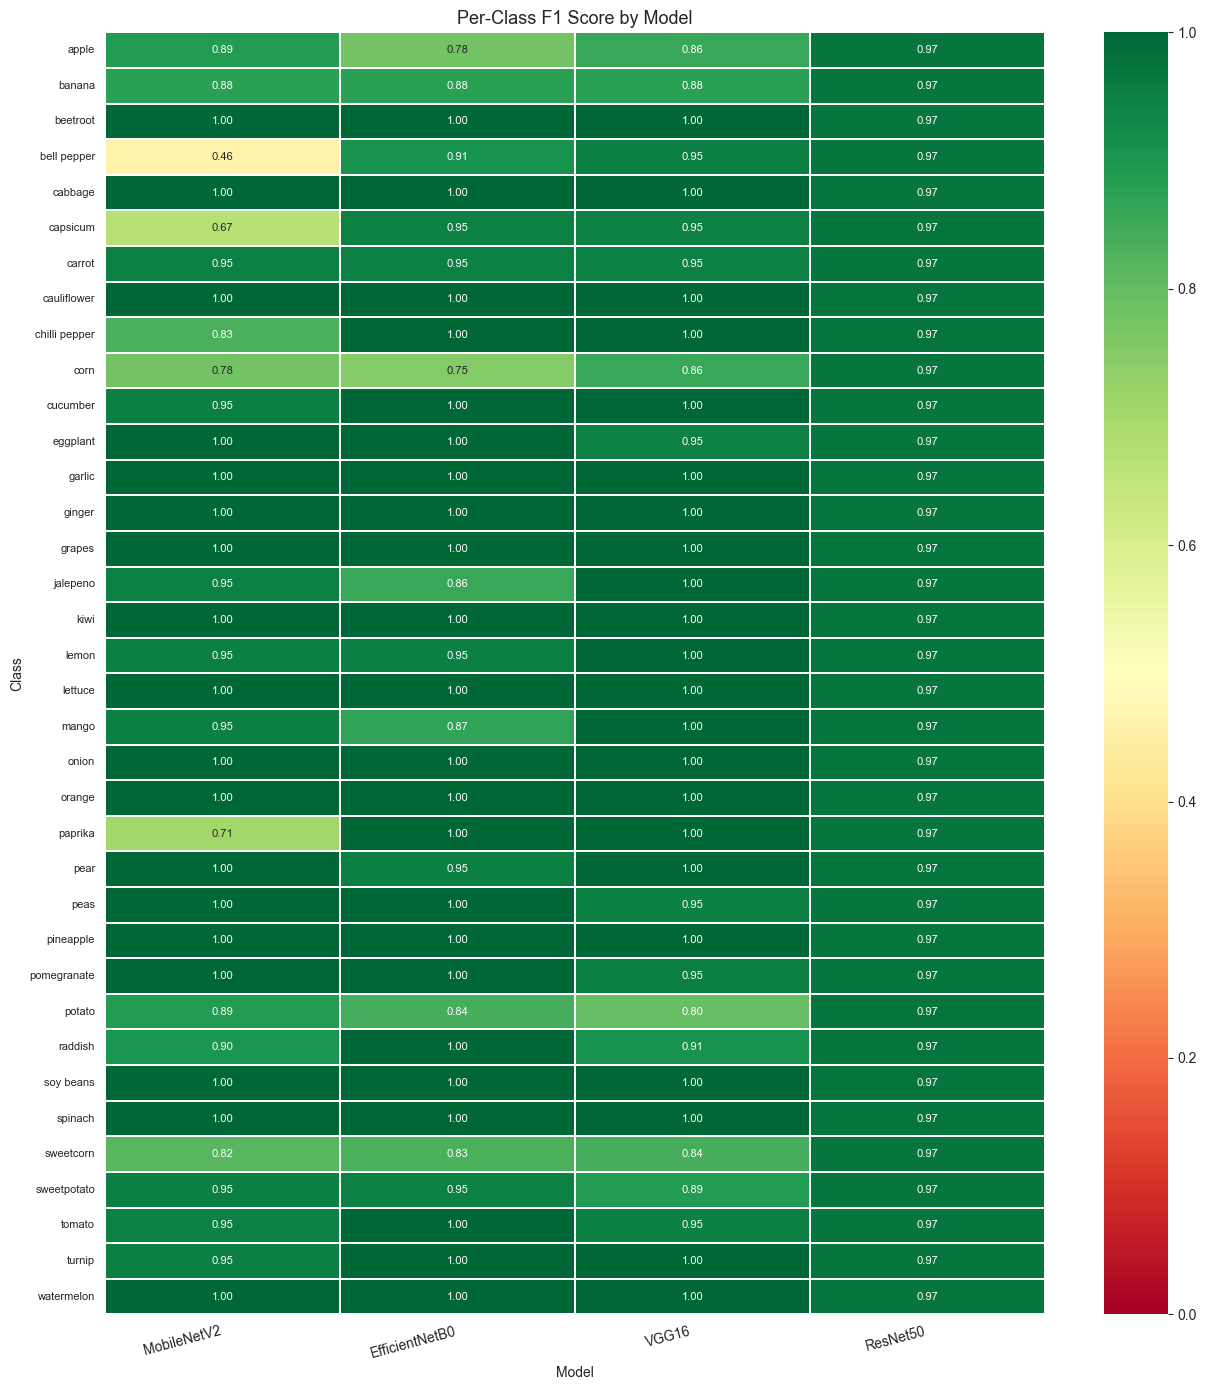

In [14]:
f1_df = pd.DataFrame(
    {name: results[name]['f1_per_class'] for name in results},
    index=CLASS_NAMES
)

fig, ax = plt.subplots(figsize=(len(results) * 3 + 1, 14))
sns.heatmap(
    f1_df, annot=True, fmt='.2f', cmap='RdYlGn',
    vmin=0, vmax=1, linewidths=0.3, ax=ax,
    annot_kws={'size': 8}
)
ax.set_title('Per-Class F1 Score by Model', fontsize=13)
ax.set_xlabel('Model')
ax.set_ylabel('Class')
plt.xticks(rotation=15, ha='right')
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'comparison_f1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Classification Reports

In [15]:
for name in results:
    print(f'=== {name} ===')
    print(classification_report(
        results[name]['y_true'],
        results[name]['y_pred'],
        target_names=CLASS_NAMES,
        digits=3
    ))
    print()

=== MobileNetV2 ===
               precision    recall  f1-score   support

        apple      1.000     0.800     0.889        10
       banana      1.000     0.778     0.875         9
     beetroot      1.000     1.000     1.000        10
  bell pepper      1.000     0.300     0.462        10
      cabbage      1.000     1.000     1.000        10
     capsicum      0.500     1.000     0.667        10
       carrot      1.000     0.900     0.947        10
  cauliflower      1.000     1.000     1.000        10
chilli pepper      0.714     1.000     0.833        10
         corn      0.875     0.700     0.778        10
     cucumber      0.909     1.000     0.952        10
     eggplant      1.000     1.000     1.000        10
       garlic      1.000     1.000     1.000        10
       ginger      1.000     1.000     1.000        10
       grapes      1.000     1.000     1.000        10
     jalepeno      1.000     0.900     0.947        10
         kiwi      1.000     1.000     1.000

## 7. Summary

In [16]:
summary = pd.DataFrame([
    {
        'Model':     name,
        'Test Acc':  f'{results[name]["accuracy"]:.4f}',
        'Test Loss': f'{results[name]["loss"]:.4f}',
        'Macro F1':  f'{results[name]["f1_macro"]:.4f}',
    }
    for name in results
]).set_index('Model')

print('=== Final Comparison ===')
print(summary.to_string())

best_acc = max(results, key=lambda n: results[n]['accuracy'])
best_f1  = max(results, key=lambda n: results[n]['f1_macro'])
print(f'\nBest test accuracy : {best_acc} ({results[best_acc]["accuracy"]*100:.2f}%)')
print(f'Best macro F1      : {best_f1}  ({results[best_f1]["f1_macro"]:.4f})')

=== Final Comparison ===
               Test Acc Test Loss Macro F1
Model                                     
MobileNetV2      0.9304    0.1900   0.9283
EfficientNetB0   0.9582    0.1961   0.9572
VGG16            0.9638    0.1327   0.9634
ResNet50         0.9721    0.1012   0.9721

Best test accuracy : ResNet50 (97.21%)
Best macro F1      : ResNet50  (0.9721)
